Họ tên: Nguyễn Huỳnh Nam Quốc  
MSSV: 2453089  
GitHub: namquoc2108-bot


# Bài tập: Tính và cập nhật trọng số bằng Gradient Descent

Mục tiêu:
- Tính dự đoán từ trọng số.
- Tính sai số và hàm mất mát.
- Tính gradient theo trọng số.
- Cập nhật trọng số theo công thức Gradient Descent.

Ràng buộc: chỉ dùng `numpy` cho phần code và `matplotlib` cho phần vẽ đồ thị.

## Công thức cần nhớ

### Linear Regression

Với mô hình tuyến tính một biến:

$$\hat{y} = wx + b$$

Hàm mất mát trung bình bình phương:

$$L = \frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i - y_i)^2$$

Gradient:

$$\frac{\partial L}{\partial w} = \frac{2}{n}\sum_{i=1}^{n}x_i(\hat{y}_i - y_i)$$

$$\frac{\partial L}{\partial b} = \frac{2}{n}\sum_{i=1}^{n}(\hat{y}_i - y_i)$$

### Logistic Regression

Với mô hình logistic regression một biến, trước hết tính điểm tuyến tính:

$$z = wx + b$$

Đổi `z` thành xác suất bằng hàm sigmoid:

$$\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}$$

Trong đó `\hat{y}` là xác suất mẫu thuộc lớp `1`.

Hàm mất mát Binary Cross Entropy cho một mẫu:

$$L = -\left[y\log(\hat{y}) + (1-y)\log(1-\hat{y})\right]$$

Hàm mất mát trung bình cho `n` mẫu:

$$L = -\frac{1}{n}\sum_{i=1}^{n}\left[y_i\log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)\right]$$

Để tránh `log(0)`, chặn xác suất dự đoán trong khoảng rất nhỏ:

$$\hat{y} \leftarrow \mathrm{clip}(\hat{y}, \epsilon, 1 - \epsilon)$$

Ví dụ: `epsilon = 1e-12`.

Với sigmoid kết hợp Binary Cross Entropy, gradient có dạng gọn:

$$\frac{\partial L}{\partial w} = \frac{1}{n}\sum_{i=1}^{n}x_i(\hat{y}_i - y_i)$$

$$\frac{\partial L}{\partial b} = \frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i - y_i)$$

### Cập nhật trọng số bằng Gradient Descent

Dùng cùng công thức cập nhật cho cả hai bài toán:

$$w \leftarrow w - \alpha\frac{\partial L}{\partial w}$$

$$b \leftarrow b - \alpha\frac{\partial L}{\partial b}$$


## Code mẫu: huấn luyện đầy đủ và quan sát loss giảm

Cell này minh họa toàn bộ quy trình Gradient Descent qua nhiều vòng lặp. Sau khi chạy, ta quan sát loss bằng biểu đồ matplotlib để thấy quá trình học diễn ra trực quan hơn.

epoch   0 | loss =  13.0789 | w =  0.405 | b =  0.700
epoch  20 | loss =   0.1158 | w =  1.901 | b =  2.585
epoch  40 | loss =   0.0645 | w =  2.182 | b =  2.441
epoch  60 | loss =   0.0359 | w =  2.389 | b =  2.329
epoch  79 | loss =   0.0206 | w =  2.538 | b =  2.249


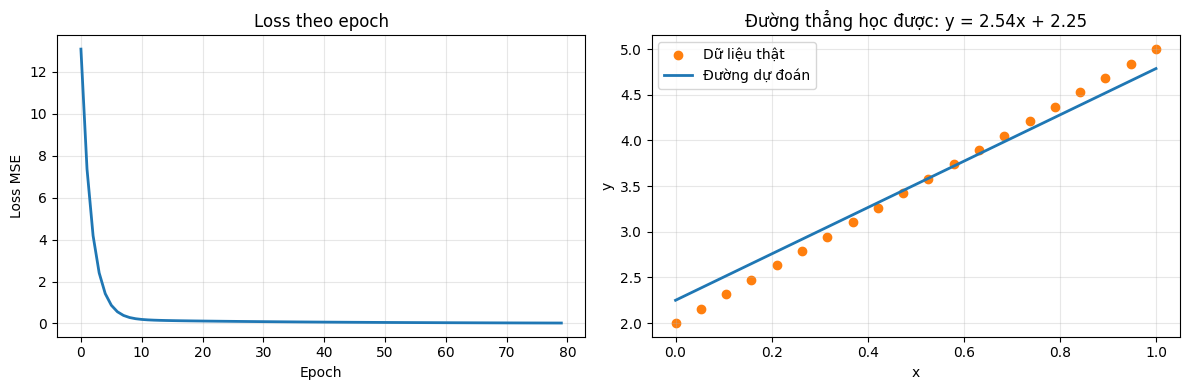


Kết quả cuối cùng:
w = 2.5375
b = 2.2493
Dự đoán khi x = 1.5: 6.0556


In [64]:
import numpy as np
import matplotlib.pyplot as plt

# Dữ liệu mẫu: y gần đúng bằng 3x + 2
# Dùng x trong khoảng 0 đến 1 để loss giảm mượt và dễ quan sát hơn.
x = np.linspace(0, 1, 20)
y = 3 * x + 2

# Khởi tạo trọng số
w = 0.0
b = 0.0
learning_rate = 0.1
epochs = 80
loss_history = []

def predict(x, w, b):
    return w * x + b

def mse_loss(y_true, y_pred):
    error = y_pred - y_true
    return np.mean(error ** 2)

def compute_gradients(x, y_true, y_pred):
    error = y_pred - y_true
    grad_w = 2 * np.mean(x * error)
    grad_b = 2 * np.mean(error)
    return grad_w, grad_b

for epoch in range(epochs):
    # Tính giá trị dự đoán
    y_pred = predict(x, w, b)

    # Tính loss
    loss = mse_loss(y, y_pred)
    loss_history.append(loss)

    # Tính gradient
    grad_w, grad_b = compute_gradients(x, y, y_pred)

    # Cập nhật trọng số
    w = w - learning_rate * grad_w
    b = b - learning_rate * grad_b

    if epoch % 20 == 0 or epoch == epochs - 1:
        print(f"epoch {epoch:3d} | loss = {loss:8.4f} | w = {w:6.3f} | b = {b:6.3f}")

def plot_training_result(loss_history, x, y_true, w, b):
    epochs_axis = np.arange(len(loss_history))
    y_pred = predict(x, w, b)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs_axis, loss_history, color="tab:blue", linewidth=2)
    axes[0].set_title("Loss theo epoch")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss MSE")
    axes[0].grid(True, alpha=0.3)

    axes[1].scatter(x, y_true, color="tab:orange", label="Dữ liệu thật")
    axes[1].plot(x, y_pred, color="tab:blue", linewidth=2, label="Đường dự đoán")
    axes[1].set_title(f"Đường thẳng học được: y = {w:.2f}x + {b:.2f}")
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("y")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_training_result(loss_history, x, y, w, b)

print("\nKết quả cuối cùng:")
print(f"w = {w:.4f}")
print(f"b = {b:.4f}")
print(f"Dự đoán khi x = 1.5: {predict(1.5, w, b):.4f}")

## Bài 1: Linear Regression với dữ liệu rải quanh một đường thẳng

Bộ dữ liệu bên dưới mô phỏng các điểm `x` nằm rải rác quanh đường thẳng thật gần đúng `y = 2.4x - 1.2`.

Yêu cầu học sinh:
- Tính dự đoán `y_pred`.
- Tính MSE loss.
- Tính gradient theo `w` và `b`.
- Cập nhật `w`, `b` bằng Gradient Descent.
- In loss để quan sát quá trình học.

In [65]:
import numpy as np

# Dữ liệu linear regression
x_linear = np.array([-3.0, -2.4, -1.8, -1.2, -0.6, 0.0, 0.6, 1.2, 1.8, 2.4, 3.0])
y_linear = np.array([-8.7, -6.6, -5.4, -4.0, -2.4, -1.0, 0.0, 1.6, 3.0, 4.7, 6.2])

# Tham số khởi tạo đã cho
w_linear = 0.3
b_linear = 0.0
learning_rate_linear = 0.03
epochs_linear = 120

print("x_linear =", x_linear)
print("y_linear =", y_linear)
print("w_linear ban đầu =", w_linear)
print("b_linear ban đầu =", b_linear)
print("learning_rate_linear =", learning_rate_linear)

x_linear = [-3.  -2.4 -1.8 -1.2 -0.6  0.   0.6  1.2  1.8  2.4  3. ]
y_linear = [-8.7 -6.6 -5.4 -4.  -2.4 -1.   0.   1.6  3.   4.7  6.2]
w_linear ban đầu = 0.3
b_linear ban đầu = 0.0
learning_rate_linear = 0.03


### Bài 1.1: Hoàn thiện hàm cho Linear Regression


In [66]:
# TODO: viết hàm predict_linear(x, w, b)
def predict_linear(x, w, b):
    return w * x + b

# TODO: viết hàm mse_loss(y_true, y_pred)
def mse_loss(y_true, y_pred):
    error = y_pred - y_true
    return np.mean(error ** 2)

# TODO: viết hàm compute_linear_gradients(x, y_true, y_pred)
def compute_linear_gradients(x, y_true, y_pred):
    n = len(x)
    error = y_pred - y_true
    
    grad_w = (2 / n) * np.sum(x * error)
    grad_b = (2 / n) * np.sum(error)
    
    return grad_w, grad_b

### Bài 1.2: Huấn luyện mô hình Linear Regression

Sau khi chạy xong, `w_linear` và `b_linear` nên tiến gần tới đường thẳng phù hợp với dữ liệu.

In [67]:
loss_history_linear = []

# TODO: chạy vòng lặp Gradient Descent trong epochs_linear
for epoch in range(epochs_linear):
# TODO: tính y_pred_linear bằng predict_linear
    y_pred_linear = predict_linear(x_linear, w_linear, b_linear)
# TODO: tính loss_linear bằng mse_loss và lưu vào loss_history_linear
    loss_linear = mse_loss(y_linear, y_pred_linear)
    loss_history_linear.append(loss_linear)
# TODO: tính grad_w_linear, grad_b_linear bằng compute_linear_gradients
    grad_w_linear, grad_b_linear = compute_linear_gradients(
            x_linear, y_linear, y_pred_linear
    )
# TODO: cập nhật w_linear = w_linear - learning_rate_linear * grad_w_linear
    w_linear = w_linear - learning_rate_linear * grad_w_linear
# TODO: cập nhật b_linear = b_linear - learning_rate_linear * grad_b_linear
    b_linear = b_linear - learning_rate_linear * grad_b_linear
# TODO: in epoch, loss_linear, w_linear, b_linear sau mỗi 20 epochs
    if epoch % 20 == 0 or epoch == epochs_linear - 1:
            print(
                f"epoch {epoch:3d} | "
                f"loss = {loss_linear:.5f} | "
                f"w = {w_linear:.5f} | "
                f"b = {b_linear:.5f}"
        )
# TODO: in kết quả cuối cùng của w_linear và b_linear
print("\nKết quả cuối cùng Linear Regression:")
print("w_linear =", round(w_linear, 5))
print("b_linear =", round(b_linear, 5))
print("loss cuối =", round(loss_history_linear[-1], 5))

epoch   0 | loss = 17.25127 | w = 0.75393 | b = -0.06873
epoch  20 | loss = 0.15166 | w = 2.38883 | b = -0.83309
epoch  40 | loss = 0.04958 | w = 2.40142 | b = -1.05484
epoch  60 | loss = 0.04107 | w = 2.40151 | b = -1.11917
epoch  80 | loss = 0.04036 | w = 2.40152 | b = -1.13783
epoch 100 | loss = 0.04029 | w = 2.40152 | b = -1.14324
epoch 119 | loss = 0.04029 | w = 2.40152 | b = -1.14477

Kết quả cuối cùng Linear Regression:
w_linear = 2.40152
b_linear = -1.14477
loss cuối = 0.04029


### Bài 1.3: Viết hàm plot kết quả Linear Regression

Viết hàm trực quan hóa để kiểm tra đường thẳng mô hình học được có khớp với dữ liệu hay không.

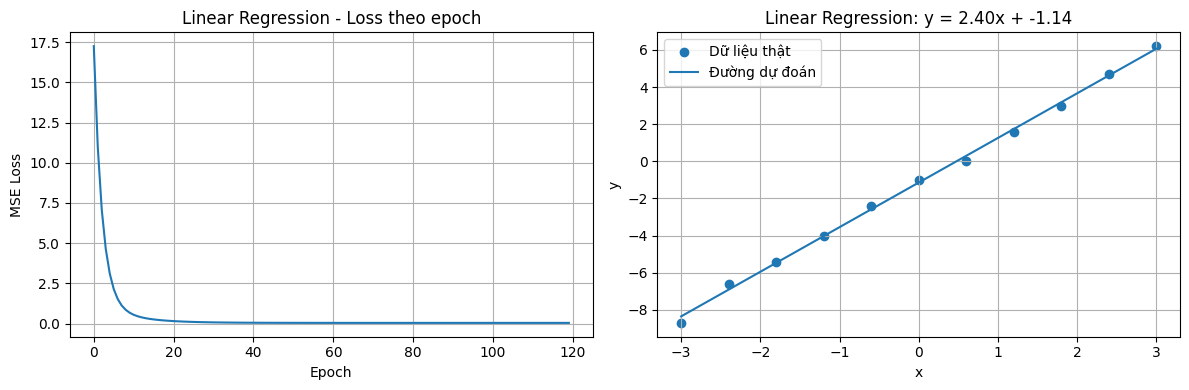

In [68]:
# TODO: import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

# TODO: viết hàm plot_linear_result(x, y_true, w, b, loss_history)
# Gợi ý: tạo biểu đồ gồm 2 phần
# - Phần 1: vẽ loss_history theo epoch
# - Phần 2: scatter dữ liệu thật và vẽ đường y_pred = w * x + b
# - Thêm title, xlabel, ylabel, legend để biểu đồ dễ đọc
def plot_linear_result(x, y_true, w, b, loss_history):
    y_pred = predict_linear(x, w, b)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    axes[0].plot(loss_history)
    axes[0].set_title("Linear Regression - Loss theo epoch")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("MSE Loss")
    axes[0].grid(True)
    
    axes[1].scatter(x, y_true, label="Dữ liệu thật")
    axes[1].plot(x, y_pred, label="Đường dự đoán")
    axes[1].set_title(f"Linear Regression: y = {w:.2f}x + {b:.2f}")
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("y")
    axes[1].legend()
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.show()

# TODO: gọi plot_linear_result(x_linear, y_linear, w_linear, b_linear, loss_history_linear)
plot_linear_result(x_linear, y_linear, w_linear, b_linear, loss_history_linear)

Nhận xét:

Lúc mới bắt đầu, em thấy loss khá lớn vì đường thẳng dự đoán ban đầu còn lệch nhiều so với các điểm dữ liệu. Khi chạy Gradient Descent qua nhiều epoch, loss giảm rất nhanh ở giai đoạn đầu rồi dần ổn định lại. Điều này cho thấy mô hình đang từng bước chỉnh lại `w` và `b` để đường thẳng tiến gần hơn với dữ liệu thật.

Kết quả cuối cùng cho ra `w` khoảng 2.4 và `b` khoảng -1.14. Khi nhìn lên biểu đồ, em thấy đường dự đoán đã đi khá sát các điểm dữ liệu, chỉ còn lệch nhẹ ở một vài điểm nhỏ. Vì dữ liệu ban đầu cũng có nhiễu chứ không nằm hoàn toàn trên một đường thẳng, nên việc loss không về đúng 0 là hợp lý.

Qua phần này, em hiểu rõ hơn ý nghĩa của Gradient Descent: mô hình không biết ngay đáp án đúng từ đầu, mà phải sửa từng chút một qua mỗi lần cập nhật để tìm được đường thẳng phù hợp hơn.

## Bài 2: Logistic Regression

Bộ dữ liệu bên dưới mô phỏng một biến đầu vào `x`. Nhãn `y = 0` thường nằm ở vùng `x` nhỏ hơn, nhãn `y = 1` thường nằm ở vùng `x` lớn hơn.

Yêu cầu học sinh:
- Tính dự đoán `z` từ trọng số.
- Đổi `z` thành xác suất bằng sigmoid.
- Tính Binary Cross Entropy loss.
- Tính gradient theo `w` và `b`.
- Cập nhật `w`, `b` bằng Gradient Descent.

In [69]:
# Dữ liệu logistic regression
x_logistic = np.array([-3.2, -2.7, -2.1, -1.5, -0.9, -0.4, 0.1, 0.5, 0.9, 1.4, 2.0, 2.6, 3.1])
y_logistic = np.array([0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1])

# Tham số khởi tạo
w_logistic = -0.2
b_logistic = 0.1
learning_rate_logistic = 0.15
epochs_logistic = 150

print("x_logistic =", x_logistic)
print("y_logistic =", y_logistic)
print("w_logistic ban đầu =", w_logistic)
print("b_logistic ban đầu =", b_logistic)
print("learning_rate_logistic =", learning_rate_logistic)

x_logistic = [-3.2 -2.7 -2.1 -1.5 -0.9 -0.4  0.1  0.5  0.9  1.4  2.   2.6  3.1]
y_logistic = [0 0 0 0 0 1 0 1 1 1 1 1 1]
w_logistic ban đầu = -0.2
b_logistic ban đầu = 0.1
learning_rate_logistic = 0.15


### Bài 2.1: Hoàn thiện hàm cho Logistic Regression

Dùng `epsilon` nhỏ khi tính log để tránh `log(0)`.

In [70]:
# TODO: viết hàm sigmoid(z)
def sigmoid(z):
    return 1 / (1 + np.exp(-z))
# TODO: viết hàm predict_proba_logistic(x, w, b)
def predict_proba_logistic(x, w, b):
    z = w * x + b
    return sigmoid(z)

# TODO: viết hàm binary_cross_entropy(y_true, y_pred_proba)
# Gợi ý:
# epsilon = 1e-12
# y_pred_proba = clip(y_pred_proba, epsilon, 1 - epsilon)
# loss = -mean(y_true * log(y_pred_proba) + (1 - y_true) * log(1 - y_pred_proba))
def binary_cross_entropy(y_true, y_pred_proba):
    epsilon = 1e-12
    y_pred_proba = np.clip(y_pred_proba, epsilon, 1 - epsilon)
    
    loss = -np.mean(
        y_true * np.log(y_pred_proba)
        + (1 - y_true) * np.log(1 - y_pred_proba)
    )
    
    return loss

# TODO: viết hàm compute_logistic_gradients(x, y_true, y_pred_proba)
def compute_logistic_gradients(x, y_true, y_pred_proba):
    n = len(x)
    error = y_pred_proba - y_true
    
    grad_w = (1 / n) * np.sum(x * error)
    grad_b = (1 / n) * np.sum(error)
    
    return grad_w, grad_b

### Bài 2.2: Huấn luyện mô hình Logistic Regression

Sau khi huấn luyện, xác suất dự đoán nên thấp hơn cho phần lớn điểm lớp `0` và cao hơn cho phần lớn điểm lớp `1`.

In [71]:
loss_history_logistic = []

# TODO: chạy vòng lặp Gradient Descent trong epochs_logistic
for epoch in range(epochs_logistic):
# TODO: tính y_pred_proba_logistic bằng predict_proba_logistic
    y_pred_proba_logistic = predict_proba_logistic(
        x_logistic, w_logistic, b_logistic
    )
# TODO: tính loss_logistic bằng binary_cross_entropy và lưu vào loss_history_logistic
    loss_logistic = binary_cross_entropy(
        y_logistic, y_pred_proba_logistic
    )
    loss_history_logistic.append(loss_logistic)
# TODO: tính grad_w_logistic, grad_b_logistic bằng compute_logistic_gradients
    grad_w_logistic, grad_b_logistic = compute_logistic_gradients(
        x_logistic, y_logistic, y_pred_proba_logistic
    )
# TODO: cập nhật w_logistic = w_logistic - learning_rate_logistic * grad_w_logistic
    w_logistic = w_logistic - learning_rate_logistic * grad_w_logistic
# TODO: cập nhật b_logistic = b_logistic - learning_rate_logistic * grad_b_logistic
    b_logistic = b_logistic - learning_rate_logistic * grad_b_logistic
# TODO: in epoch, loss_logistic, w_logistic, b_logistic sau mỗi 25 epochs
    if epoch % 25 == 0 or epoch == epochs_logistic - 1:
        print(
            f"epoch {epoch:3d} | "
            f"loss = {loss_logistic:.5f} | "
            f"w = {w_logistic:.5f} | "
            f"b = {b_logistic:.5f}"
        )

# TODO: tính xác suất cuối cùng cho từng điểm x_logistic
final_proba_logistic = predict_proba_logistic(
x_logistic, w_logistic, b_logistic
)
# TODO: đổi xác suất thành nhãn dự đoán với ngưỡng 0.5
y_pred_label_logistic = (final_proba_logistic >= 0.5).astype(int)
# TODO: in xác suất, nhãn dự đoán, và so sánh với y_logistic
print("\nKết quả cuối cùng Logistic Regression:")
print("w_logistic =", round(w_logistic, 5))
print("b_logistic =", round(b_logistic, 5))
print("loss cuối =", round(loss_history_logistic[-1], 5))

print("\nSo sánh dự đoán:")
for x_val, y_true, proba, y_pred in zip(
    x_logistic, y_logistic, final_proba_logistic, y_pred_label_logistic
):
    print(
        f"x = {x_val:5.2f} | "
        f"y thật = {y_true} | "
        f"xác suất lớp 1 = {proba:.4f} | "
        f"y dự đoán = {y_pred}"
    )

accuracy = np.mean(y_pred_label_logistic == y_logistic)
print("\nAccuracy =", round(accuracy, 4))

epoch   0 | loss = 0.86596 | w = -0.05495 | b = 0.10205
epoch  25 | loss = 0.26696 | w = 1.11215 | b = 0.16128
epoch  50 | loss = 0.23001 | w = 1.46720 | b = 0.21433
epoch  75 | loss = 0.21669 | w = 1.68253 | b = 0.25664
epoch 100 | loss = 0.20997 | w = 1.83558 | b = 0.29080
epoch 125 | loss = 0.20603 | w = 1.95267 | b = 0.31880
epoch 149 | loss = 0.20360 | w = 2.04276 | b = 0.34118

Kết quả cuối cùng Logistic Regression:
w_logistic = 2.04276
b_logistic = 0.34118
loss cuối = 0.2036

So sánh dự đoán:
x = -3.20 | y thật = 0 | xác suất lớp 1 = 0.0020 | y dự đoán = 0
x = -2.70 | y thật = 0 | xác suất lớp 1 = 0.0056 | y dự đoán = 0
x = -2.10 | y thật = 0 | xác suất lớp 1 = 0.0189 | y dự đoán = 0
x = -1.50 | y thật = 0 | xác suất lớp 1 = 0.0616 | y dự đoán = 0
x = -0.90 | y thật = 0 | xác suất lớp 1 = 0.1828 | y dự đoán = 0
x = -0.40 | y thật = 1 | xác suất lớp 1 = 0.3832 | y dự đoán = 0
x =  0.10 | y thật = 0 | xác suất lớp 1 = 0.6331 | y dự đoán = 1
x =  0.50 | y thật = 1 | xác suất lớp 1 

Nhận xét:

Ở phần Logistic Regression, lúc đầu em thấy loss khá cao, khoảng 0.866, vì mô hình bắt đầu với `w` và `b` chưa phù hợp nên ranh giới phân loại còn rất lệch. Sau khi chạy Gradient Descent, loss giảm dần xuống còn khoảng 0.2036. Điều này cho thấy mô hình đã học được xu hướng chính của dữ liệu: khi `x` càng lớn thì khả năng thuộc lớp 1 càng cao.

Nhìn vào kết quả dự đoán, các điểm có `x` âm lớn như -3.2, -2.7, -2.1 đều có xác suất lớp 1 rất thấp và được dự đoán là lớp 0. Ngược lại, các điểm có `x` lớn như 1.4, 2.0, 2.6, 3.1 đều có xác suất lớp 1 gần 1 và được dự đoán đúng là lớp 1. Phần này làm em thấy mô hình đã bắt được xu hướng tổng quát khá tốt.

Tuy nhiên, mô hình vẫn bị sai ở một vài điểm gần vùng ranh giới. Ví dụ `x = -0.40` có nhãn thật là 1 nhưng xác suất dự đoán chỉ khoảng 0.3832 nên bị phân loại thành 0. Ngược lại, `x = 0.10` có nhãn thật là 0 nhưng xác suất dự đoán khoảng 0.6331 nên bị phân loại thành 1. Hai điểm này nằm khá gần vùng chuyển tiếp giữa hai lớp, nên em thấy việc mô hình nhầm là hợp lý.

Accuracy cuối cùng là 0.8462, tức là mô hình dự đoán đúng 11/13 điểm. Kết quả này chưa hoàn hảo, nhưng em thấy chấp nhận được vì dữ liệu không tách sạch hoàn toàn. Qua phần này em hiểu rõ hơn là Logistic Regression không chỉ cho ra nhãn 0 hoặc 1, mà còn cho biết mức độ “tự tin” của mô hình thông qua xác suất. Những điểm càng gần ngưỡng 0.5 thì mô hình càng dễ phân loại nhầm.

### Bài 2.3: Viết hàm plot kết quả Logistic Regression

Viết hàm trực quan hóa để kiểm tra loss giảm và xác suất dự đoán theo từng điểm dữ liệu.

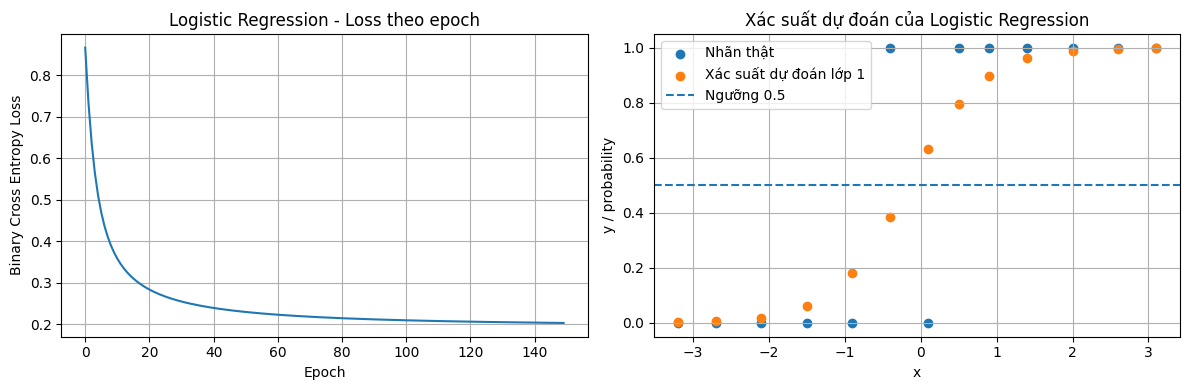

In [72]:
# TODO: import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

# TODO: viết hàm plot_logistic_result(x, y_true, y_pred_proba, loss_history)
# Gợi ý: tạo biểu đồ gồm 2 phần
# - Phần 1: vẽ loss_history theo epoch
# - Phần 2: scatter dữ liệu thật và scatter xác suất dự đoán
# - Có thể vẽ thêm đường ngang y = 0.5 để thể hiện ngưỡng phân lớp
# - Thêm title, xlabel, ylabel, legend để biểu đồ dễ đọc
def plot_logistic_result(x, y_true, y_pred_proba, loss_history):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    axes[0].plot(loss_history)
    axes[0].set_title("Logistic Regression - Loss theo epoch")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Binary Cross Entropy Loss")
    axes[0].grid(True)
    
    axes[1].scatter(x, y_true, label="Nhãn thật")
    axes[1].scatter(x, y_pred_proba, label="Xác suất dự đoán lớp 1")
    axes[1].axhline(0.5, linestyle="--", label="Ngưỡng 0.5")
    axes[1].set_title("Xác suất dự đoán của Logistic Regression")
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("y / probability")
    axes[1].legend()
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.show()

# TODO: tính final_proba_logistic bằng predict_proba_logistic(x_logistic, w_logistic, b_logistic)
final_proba_logistic = predict_proba_logistic(
    x_logistic, w_logistic, b_logistic
)
# TODO: gọi plot_logistic_result(x_logistic, y_logistic, final_proba_logistic, loss_history_logistic)
plot_logistic_result(
    x_logistic,
    y_logistic,
    final_proba_logistic,
    loss_history_logistic
)

Nhận xét:

Nhìn vào biểu đồ loss bên trái, em thấy loss giảm khá mạnh ở những epoch đầu, sau đó giảm chậm dần và gần như ổn định quanh mức 0.2. Điều này cho thấy Gradient Descent đang đi đúng hướng: ban đầu mô hình còn đoán khá lệch, nhưng sau nhiều lần cập nhật thì `w` và `b` được chỉnh tốt hơn nên lỗi giảm xuống.

Ở biểu đồ bên phải, các điểm màu cam là xác suất mô hình dự đoán thuộc lớp 1. Khi `x` còn nhỏ, xác suất này gần 0, còn khi `x` tăng dần thì xác suất cũng tăng lên gần 1. Em thấy đường cong xác suất này khá hợp lý vì dữ liệu thật cũng có xu hướng: bên trái chủ yếu là lớp 0, bên phải chủ yếu là lớp 1.

Tuy nhiên, vẫn có vài điểm làm mô hình hơi khó xử, đặc biệt là các điểm nằm gần ngưỡng 0.5. Ví dụ quanh vùng `x = -0.4` đến `x = 0.1`, xác suất bắt đầu chuyển từ thấp sang cao nên mô hình rất dễ phân loại nhầm. Điều này làm em hiểu rằng Logistic Regression không phải lúc nào cũng tách được dữ liệu hoàn hảo, nhất là khi dữ liệu có điểm nhiễu hoặc hai lớp bị chồng lên nhau một chút.

Nhìn chung, mô hình đã học được xu hướng chính của dữ liệu. Dù chưa đúng tuyệt đối, kết quả này vẫn hợp lý vì bài toán chỉ dùng một biến `x` để phân loại, nên ranh giới mà mô hình học được còn khá đơn giản.